상위 올림픽 랭킹
                   edition  total  rank
1729  2018 Winter Olympics     17     1
1675  2010 Winter Olympics     14     2
1651  2006 Winter Olympics     11     3
1766  2022 Winter Olympics      9     4
1709  2014 Winter Olympics      8     5
1605  1998 Winter Olympics      6     6
1580  1994 Winter Olympics      6     6
1634  2002 Winter Olympics      4     7
1564  1992 Winter Olympics      4     7


C:\Users\KDS21\AppData\Local\Temp\ipykernel_20256\824100845.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  korea_df['rank'] = korea_df['total'].rank(ascending = False, method = 'dense').astype('int')


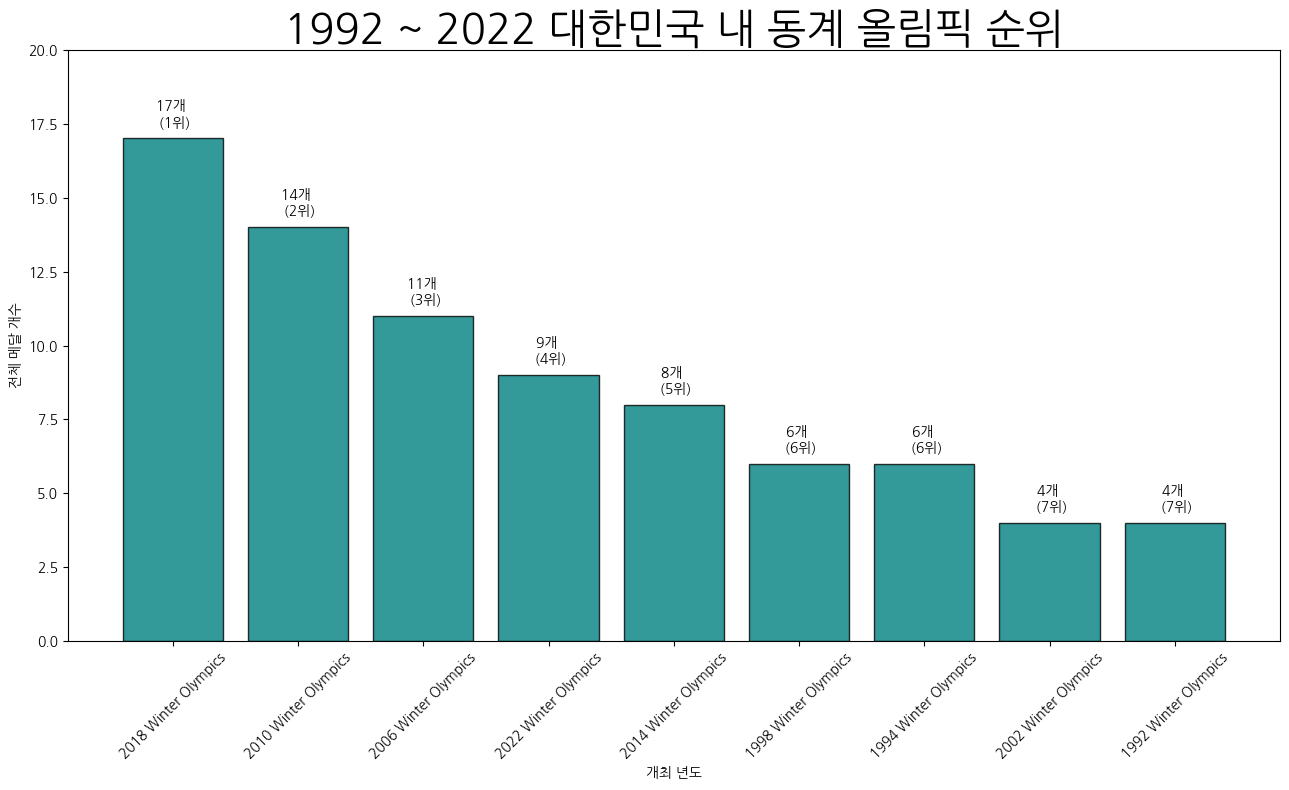

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

df = pd.read_csv('Olympic_Games_Medal_Tally.csv')

winter_df = df[df['edition'].str.contains('Winter Olympics')]
korea_df = winter_df[winter_df['country_noc'].str.contains('KOR')]

korea_df['rank'] = korea_df['total'].rank(ascending = False, method = 'dense').astype('int')
print('상위 올림픽 랭킹')
print(korea_df[['edition', 'total', 'rank']].sort_values(by = 'rank'))

data = {'edition' : ['2018 Winter Olympics', '2010 Winter Olympics', '2006 Winter Olympics', '2022 Winter Olympics', '2014 Winter Olympics', '1998 Winter Olympics', '1994 Winter Olympics', '2002 Winter Olympics', '1992 Winter Olympics'],
        'total' : [17, 14, 11, 9, 8, 6, 6, 4, 4],
        'rank' : [1, 2, 3, 4, 5, 6, 6, 7, 7]}
df_rank = pd.DataFrame(data)

plt.figure(figsize = (13, 8))

bars = plt.bar(df_rank['edition'], df_rank['total'], color = 'teal', alpha = 0.8, edgecolor = 'black')

plt.title('1992 ~ 2022 대한민국 내 동계 올림픽 순위', fontsize = 30)
plt.xlabel('개최 년도')
plt.ylabel('전체 메달 개수')
plt.xticks(rotation = 45)

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., height + 0.3, f'{int(height)}개 \n ({df_rank['rank'][i]}위)',
             ha = 'center', va = 'bottom')

plt.ylim(0, 20)
plt.tight_layout()
plt.show()

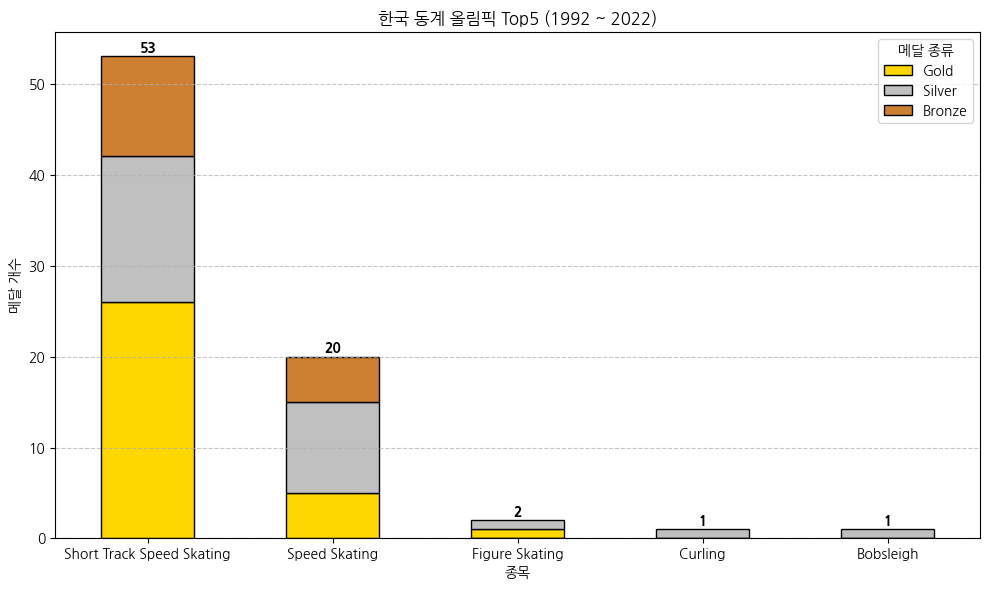

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

df = pd.read_csv('Olympic_Athlete_Event_Results.csv')

# 한국 동계 올림픽 데이터 필터링
winter_korea = df[(df['edition'].str.contains('Winter')) & (df['country_noc'] == 'KOR')].copy()

# 메달 획득 데이터만 추출 및 단체전 중복 제거
# 한 경기에 여러 선수가 있어도 메달은 1개로 집계
korea_medals = winter_korea[winter_korea['medal'].notna()].drop_duplicates(subset=['edition', 'sport', 'event', 'medal'])

# 종목별(sport)로 메달 종류(medal) 개수 집계
medal_counts = korea_medals.groupby(['sport', 'medal']).size().unstack(fill_value=0)

# 금, 은, 동 순서 정렬 및 상위 5개 종목 선정 (합계 기준)
medal_counts['total'] = medal_counts.sum(axis=1)
top5_sports = medal_counts.sort_values(by='total', ascending=False).head(5)

# 금, 은, 동 순서로 컬럼 정렬
plot_data = top5_sports[['Gold', 'Silver', 'Bronze']]

# 누적 막대 그래프 그리기
ax = plot_data.plot(kind='bar', stacked=True, color=['#FFD700', '#C0C0C0', '#CD7F32'], figsize=(10, 6), edgecolor='black')

plt.title('한국 동계 올림픽 Top5 (1992 ~ 2022)')
plt.xlabel('종목')
plt.ylabel('메달 개수')
plt.xticks(rotation=0)
plt.legend(title='메달 종류')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 막대 위에 총 합계 숫자 표시
for i, total in enumerate(top5_sports['total']):
    ax.text(i, total + 0.5, int(total), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

df = pd.read_csv('Olympic_Athlete_Event_Results.csv')

# 한국 동계 올림픽 데이터 필터링
winter_korea = df[(df['edition'].str.contains('Winter')) & (df['country_noc'] == 'KOR')].copy()

# 기간 필터링 (2014, 2018, 2022 대회), 'edition' 컬럼에서 해당 연도가 포함된 행만 가져온다.
years = ['2014', '2018', '2022']
period_df1 = winter_korea[winter_korea['edition'].str.contains('2014')]
period_df2 = winter_korea[winter_korea['edition'].str.contains('2018')]
period_df3 = winter_korea[winter_korea['edition'].str.contains('2022')]
period_df = pd.concat([period_df1, period_df2, period_df3])

# 메달 중복 제거 (단체전 고려) 및 메달 획득 행만 남기기
korea_medals = period_df[period_df['medal'].notna()].drop_duplicates(subset=['edition', 'sport', 'event', 'medal'])

# 종목별 메달 합계 계산 및 상위 5개 추출
top5_recent = korea_medals['sport'].value_counts().head(5)

# 시리즈를 데이터프레임으로 변환 (reset_index)
top5_df = top5_recent.reset_index()

print("2014 ~ 2022 대한민국 동계 올림픽 상위 5개 종목")
print(top5_recent)

sns.lineplot(data = top5_recent, x = 'sport', y = 'korea_medals', hue = 'years', style = 'years', markers = True)

plt.title("한국 동계 올림픽 Top5 (2014 ~ 2022)")
plt.show()

2014 ~ 2022 대한민국 동계 올림픽 상위 5개 종목
sport
Short Track Speed Skating    16
Speed Skating                13
Figure Skating                1
Bobsleigh                     1
Curling                       1
Name: count, dtype: int64


TypeError: Data source must be a DataFrame or Mapping, not <class 'pandas.core.series.Series'>.

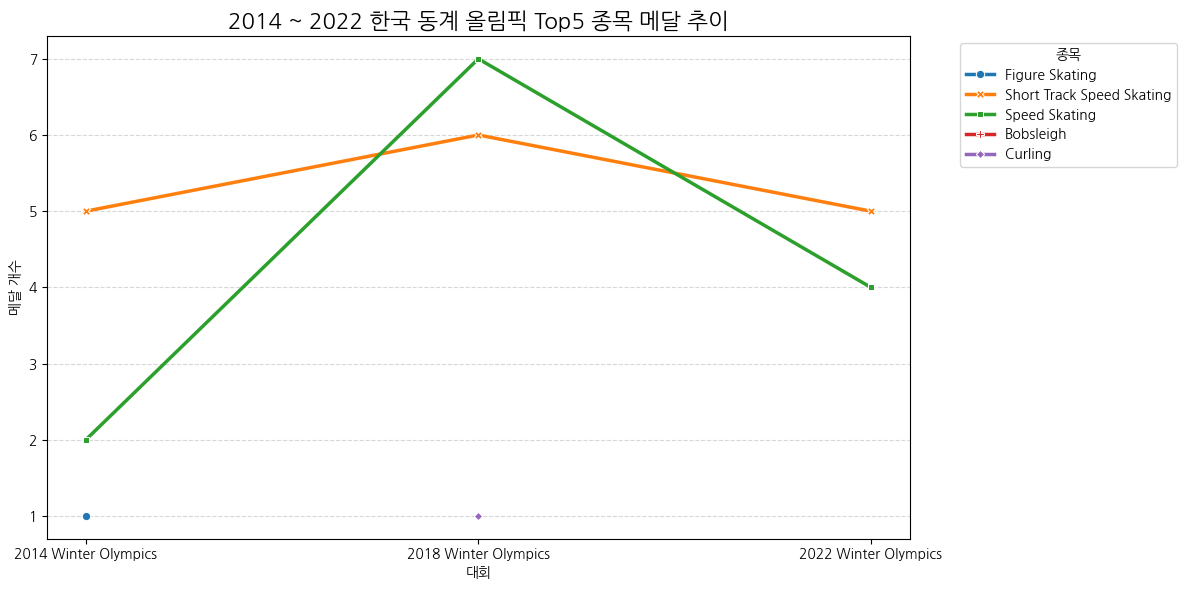

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

df = pd.read_csv('Olympic_Athlete_Event_Results.csv')

# 1. 데이터 필터링 (한국 동계 + 2014, 2018, 2022)
winter_korea = df[(df['edition'].str.contains('Winter')) & (df['country_noc'] == 'KOR')].copy()
years_pattern = '2014|2018|2022'
period_df = winter_korea[winter_korea['edition'].str.contains(years_pattern)].copy()

# 2. 메달 중복 제거 (단체전 고려)
korea_medals = period_df[period_df['medal'].notna()].drop_duplicates(subset=['edition', 'sport', 'event', 'medal'])

# 3. [핵심] 상위 5개 종목의 '연도별' 데이터 만들기
top5_names = korea_medals['sport'].value_counts().head(5).index
top5_data = korea_medals[korea_medals['sport'].isin(top5_names)]

# 연도(edition)와 종목(sport)별로 그룹화하여 개수 세기
# reset_index를 해줘야 'edition', 'sport'가 컬럼으로 올라와 Seaborn이 인식합니다.
chart_data = top5_data.groupby(['edition', 'sport']).size().reset_index(name='medal_count')

# 4. Seaborn으로 그래프 그리기
plt.figure(figsize=(12, 6))

# data: 데이터프레임 이름
# x, y: 컬럼 이름 (문자열)
# hue: 선 색상을 구분할 기준 (종목별)
# style: 선 모양을 구분할 기준 (종목별)
sns.lineplot(data=chart_data, x='edition', y='medal_count', 
             hue='sport', style='sport', markers=True, dashes=False, linewidth=2.5)

plt.title("2014 ~ 2022 한국 동계 올림픽 Top5 종목 메달 추이", fontsize=16)
plt.ylabel("메달 개수")
plt.xlabel("대회")
plt.legend(title="종목", bbox_to_anchor=(1.05, 1), loc='upper left') # 범례를 그래프 밖으로
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
C:\Users\KDS21\AppData\Local\Temp\ipykernel_17144\1983638525.py:12: SyntaxWarning: invalid escape sequence '\d'
  winter_olympic['Year'] = winter_olympic['edition'].str.extract('(\d+)').astype(int)


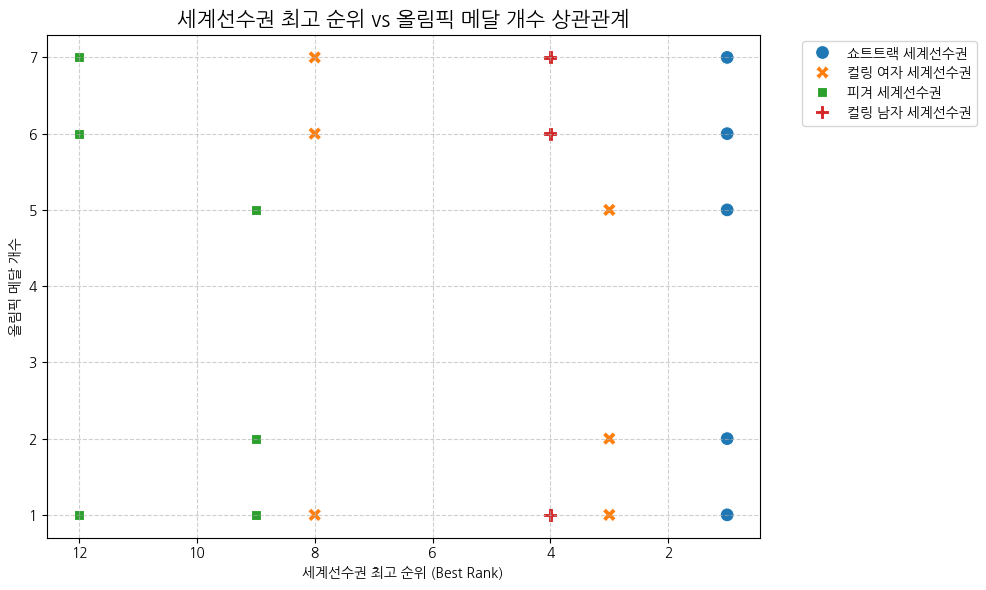

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 1. 데이터 로드
winter_olympic = pd.read_csv('winter_korea_df_all_sports.csv')
world_championship = pd.read_csv('korea_best_ranks_2011_2021_world_championships_wikipedia.csv')

# 2. 올림픽 데이터 전처리 (연도별/종목별 메달 개수 집계)
# '2018 Winter Olympics'에서 '2018'만 추출하여 숫자형 Year 컬럼 생성
winter_olympic['Year'] = winter_olympic['edition'].str.extract('(\d+)').astype(int)
# 메달 중복 제거 후 집계
olympic_medals = winter_olympic[winter_olympic['medal'].notna()].drop_duplicates(
    subset=['edition', 'sport', 'event', 'medal']
).groupby(['Year', 'sport']).size().reset_index(name='Olympic_Medals')

# 3. 세계선수권 데이터 전처리 (Best_Rank를 숫자로 변환)
# 'Best_Rank'에 문자가 섞여있을 수 있으므로 숫자로 변환
world_championship['Best_Rank'] = pd.to_numeric(world_championship['Best_Rank'], errors='coerce')

# 4. 두 데이터 병합 (Year와 Sport 기준)
# 주의: 종목명이 서로 다를 수 있으므로(예: 쇼트트랙 vs Short Track...) 확인이 필요하지만,
# 여기서는 공통된 데이터가 있다고 가정하고 병합합니다.
combined_df = pd.merge(olympic_medals, world_championship, on=['Year'], how='inner')

# 5. 산점도 그리기
plt.figure(figsize=(10, 6))
sns.scatterplot(data=combined_df, x='Best_Rank', y='Olympic_Medals', 
                hue='Sport', s=100, style='Sport')

# 산점도 분석을 돕는 설정
plt.title('세계선수권 최고 순위 vs 올림픽 메달 개수 상관관계', fontsize=15)
plt.xlabel('세계선수권 최고 순위 (Best Rank)')
plt.ylabel('올림픽 메달 개수')
plt.gca().invert_xaxis() # 순위는 숫자가 낮을수록(1등) 좋은 것이므로 x축을 뒤집음
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
C:\Users\KDS21\AppData\Local\Temp\ipykernel_17144\2517993069.py:11: SyntaxWarning: invalid escape sequence '\d'
  olympic_df['Year'] = olympic_df['edition'].str.extract('(\d+)').astype(int)


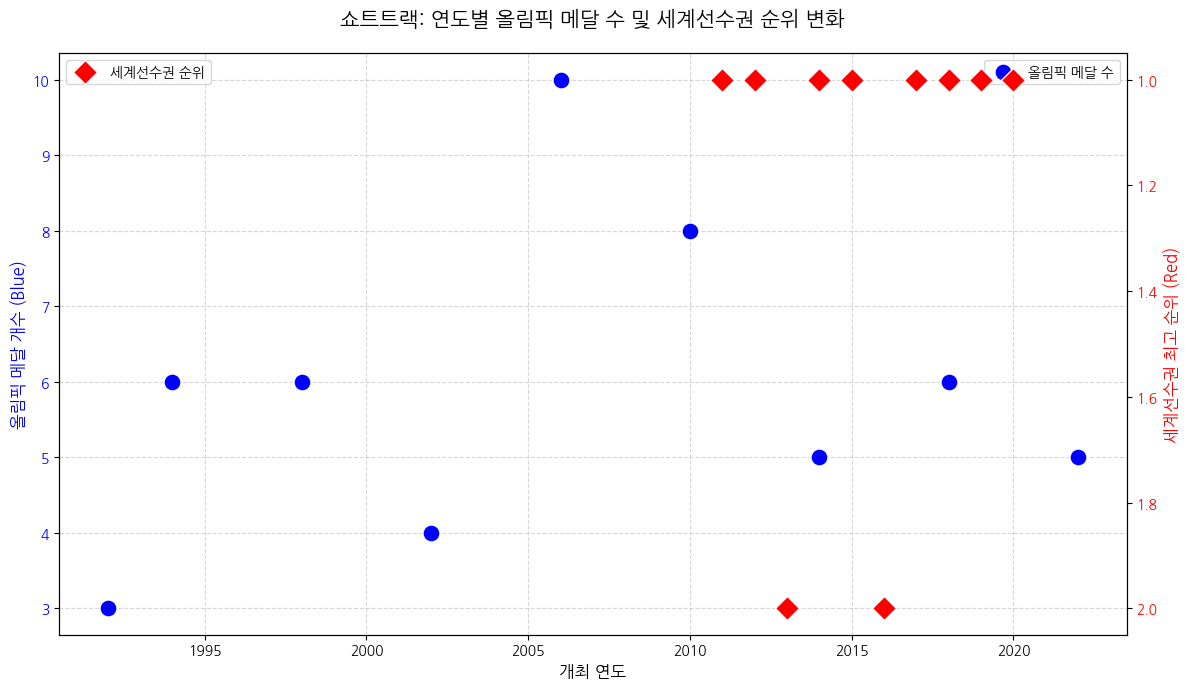

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 1. 데이터 로드
olympic_df = pd.read_csv('winter_korea_df_all_sports.csv')
world_df = pd.read_csv('korea_best_ranks_2011_2021_world_championships_wikipedia.csv')

# 2. 올림픽 데이터 전처리 (쇼트트랙 예시)
olympic_df['Year'] = olympic_df['edition'].str.extract('(\d+)').astype(int)
st_olympic = olympic_df[(olympic_df['sport'].str.contains('Short Track')) & (olympic_df['medal'].notna())]
st_olympic = st_olympic.drop_duplicates(subset=['edition', 'event', 'medal'])
st_olympic_grouped = st_olympic.groupby('Year').size().reset_index(name='Olympic_Medals')

# 3. 세계선수권 데이터 전처리 (쇼트트랙 예시)
st_world = world_df[world_df['Sport'].str.contains('쇼트트랙')].copy()
st_world['Best_Rank'] = pd.to_numeric(st_world['Best_Rank'], errors='coerce')

# 4. 그래프 그리기
fig, ax1 = plt.subplots(figsize=(12, 7))

# --- 첫 번째 y축: 올림픽 메달 개수 (왼쪽) ---
sns.scatterplot(data=st_olympic_grouped, x='Year', y='Olympic_Medals', 
                color='blue', s=150, label='올림픽 메달 수', ax=ax1, zorder=3)
ax1.set_xlabel('개최 연도', fontsize=12)
ax1.set_ylabel('올림픽 메달 개수 (Blue)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, linestyle='--', alpha=0.5)

# --- 두 번째 y축: 세계선수권 순위 (오른쪽) ---
ax2 = ax1.twinx() # x축을 공유하는 이중축 생성
sns.scatterplot(data=st_world, x='Year', y='Best_Rank', 
                color='red', s=150, marker='D', label='세계선수권 순위', ax=ax2, zorder=3)
ax2.set_ylabel('세계선수권 최고 순위 (Red)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# 순위이므로 오른쪽 축은 뒤집기 (1위가 위로 가도록)
ax2.invert_yaxis() 

# 5. 마무리
plt.title('쇼트트랙: 연도별 올림픽 메달 수 및 세계선수권 순위 변화', fontsize=15, pad=20)
fig.tight_layout()
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
C:\Users\KDS21\AppData\Local\Temp\ipykernel_17144\2602304231.py:11: SyntaxWarning: invalid escape sequence '\d'
  olympic_df['Year'] = olympic_df['edition'].str.extract('(\d+)').astype(int)
C:\Users\KDS21\AppData\Local\Temp\ipykernel_17144\2602304231.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(st_world['Year'], rotation=45)


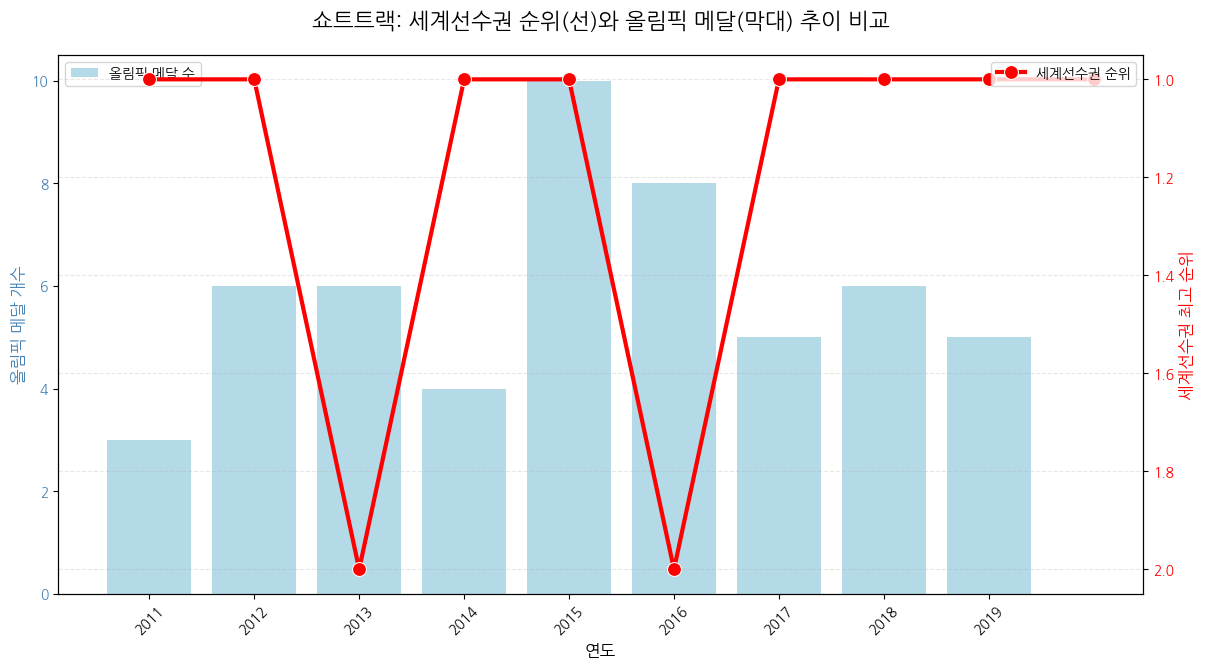

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 데이터 로드 및 전처리
olympic_df = pd.read_csv('winter_korea_df_all_sports.csv')
world_df = pd.read_csv('korea_best_ranks_2011_2021_world_championships_wikipedia.csv')

# 올림픽 데이터: 연도 추출 및 쇼트트랙 메달 집계
olympic_df['Year'] = olympic_df['edition'].str.extract('(\d+)').astype(int)
st_olympic = olympic_df[(olympic_df['sport'].str.contains('Short Track')) & (olympic_df['medal'].notna())]
st_olympic = st_olympic.drop_duplicates(subset=['edition', 'event', 'medal'])
st_olympic_grouped = st_olympic.groupby('Year').size().reset_index(name='Olympic_Medals')

# 세계선수권 데이터: 쇼트트랙 순위 추출
st_world = world_df[world_df['Sport'].str.contains('쇼트트랙')].copy()
st_world['Best_Rank'] = pd.to_numeric(st_world['Best_Rank'], errors='coerce')

# 그래프 그리기
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- [왼쪽 축] 올림픽 메달 수 (막대 그래프) ---
sns.barplot(data=st_olympic_grouped, x='Year', y='Olympic_Medals', 
            color='skyblue', alpha=0.7, ax=ax1, label='올림픽 메달 수')
ax1.set_ylabel('올림픽 메달 개수', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# --- [오른쪽 축] 세계선수권 순위 (선 그래프) ---
ax2 = ax1.twinx()
sns.lineplot(data=st_world, x=st_world.index, y='Best_Rank', 
             color='red', marker='o', linewidth=3, markersize=10, ax=ax2, label='세계선수권 순위')

# x축 연도 라벨을 세계선수권 데이터의 연도로 맞춤
ax1.set_xticklabels(st_world['Year'], rotation=45)
ax1.set_xlabel('연도', fontsize=12)

# 순위이므로 오른쪽 축 뒤집기 (1위가 위로 가도록)
ax2.set_ylabel('세계선수권 최고 순위', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.invert_yaxis() 

# 마무리
plt.title('쇼트트랙: 세계선수권 순위(선)와 올림픽 메달(막대) 추이 비교', fontsize=16, pad=20)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
C:\Users\KDS21\AppData\Local\Temp\ipykernel_20256\2237151829.py:11: SyntaxWarning: invalid escape sequence '\d'
  olympic_df['Year'] = olympic_df['edition'].str.extract('(\d+)').astype(int)
C:\Users\KDS21\AppData\Local\Temp\ipykernel_20256\2237151829.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=st_olympic_grouped, x='Year', y='Olympic_Medals',
C:\Users\KDS21\AppData\Local\Temp\ipykernel_20256\2237151829.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(st_world['Year'].tolist() + [2022], rotation=45) # 2022년 추가
C:\Users\KDS21\AppData\Local\Temp\ipykernel_20256\2237151829.py:11: SyntaxWarning: invalid escape sequence '\d

NameError: name 'lines' is not defined

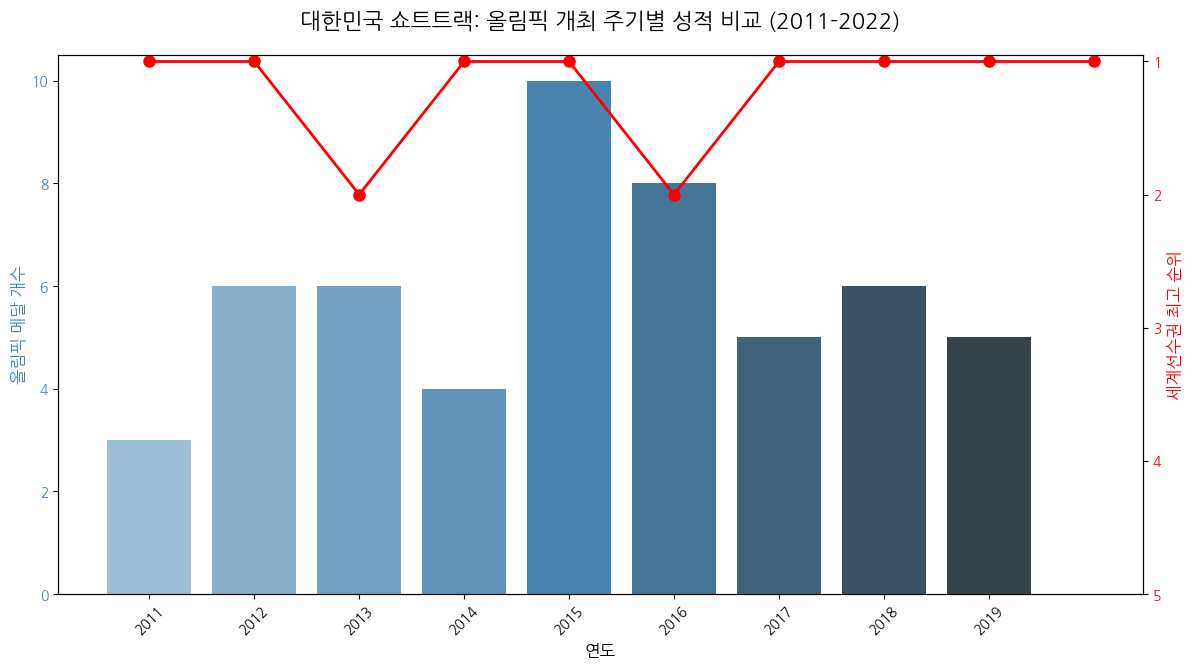

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 데이터 로드 및 전처리
olympic_df = pd.read_csv('winter_korea_df_all_sports.csv')
world_df = pd.read_csv('korea_best_ranks_2011_2021_world_championships_wikipedia.csv')

# 올림픽 데이터: 연도별 쇼트트랙 메달 집계 (중복 제거)
olympic_df['Year'] = olympic_df['edition'].str.extract('(\d+)').astype(int)
st_olympic = olympic_df[(olympic_df['sport'].str.contains('Short Track')) & (olympic_df['medal'].notna())]
st_olympic = st_olympic.drop_duplicates(subset=['edition', 'event', 'medal'])
st_olympic_grouped = st_olympic.groupby('Year').size().reset_index(name='Olympic_Medals')

# 세계선수권 데이터: 쇼트트랙 순위 추출 및 숫자 변환
st_world = world_df[world_df['Sport'].str.contains('쇼트트랙')].copy()
st_world['Best_Rank'] = pd.to_numeric(st_world['Best_Rank'], errors='coerce')

# 그래프 그리기
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- [왼쪽 축] 올림픽 개최 연도에만 막대 그래프 ---
# x축 범위를 2011년부터 2022년까지 넓혀서 올림픽 주기가 보이게 함
sns.barplot(data=st_olympic_grouped, x='Year', y='Olympic_Medals', 
            palette='Blues_d', ax=ax1, label='올림픽 메달 수')

ax1.set_xlabel('연도', fontsize=12)
ax1.set_ylabel('올림픽 메달 개수', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# --- [오른쪽 축] 세계선수권 순위 (선 그래프는 매년 연결) ---
ax2 = ax1.twinx()
# 막대 그래프의 x축 인덱스에 맞추기 위해 x축 눈금을 재설정
ax2.plot(range(len(st_world)), st_world['Best_Rank'], 
         color='red', marker='o', linewidth=2, markersize=8, label='세계선수권 순위')

# y축(순위) 뒤집기 (1위가 상단)
ax2.set_ylabel('세계선수권 최고 순위', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.invert_yaxis() 
ax2.set_yticks([1, 2, 3, 4, 5]) # 순위 눈금을 깔끔하게 지정

# 마무리 (x축 라벨 정리)
plt.title('대한민국 쇼트트랙: 올림픽 개최 주기별 성적 비교 (2011-2022)', fontsize=16, pad=20)
ax1.set_xticklabels(st_world['Year'].tolist() + [2022], rotation=45) # 2022년 추가

# 범례 통합
lines

<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
C:\Users\KDS21\AppData\Local\Temp\ipykernel_20256\3264771070.py:11: SyntaxWarning: invalid escape sequence '\d'
  olympic_df['Year'] = olympic_df['edition'].str.extract('(\d+)').astype(int)
C:\Users\KDS21\AppData\Local\Temp\ipykernel_20256\3264771070.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(all_years) # x축 눈금을 모든 연도로 표시


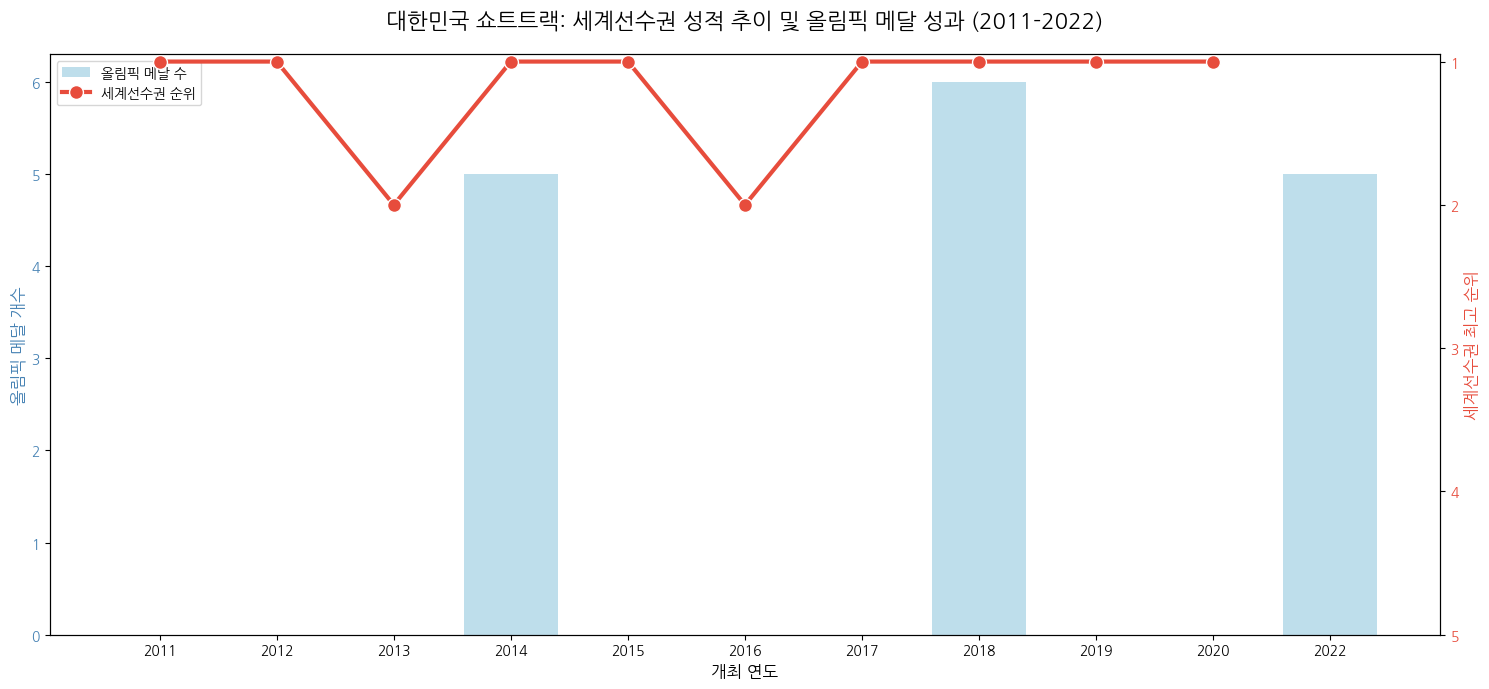

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 1. 데이터 로드 및 전처리
olympic_df = pd.read_csv('winter_korea_df_all_sports.csv')
world_df = pd.read_csv('korea_best_ranks_2011_2021_world_championships_wikipedia.csv')

# 올림픽 데이터: 연도 추출 및 쇼트트랙 메달 집계
olympic_df['Year'] = olympic_df['edition'].str.extract('(\d+)').astype(int)
st_olympic = olympic_df[(olympic_df['sport'].str.contains('Short Track')) & (olympic_df['medal'].notna())]
st_olympic = st_olympic.drop_duplicates(subset=['edition', 'event', 'medal'])
st_olympic_grouped = st_olympic.groupby('Year').size().reset_index(name='Olympic_Medals')

# 세계선수권 데이터: 쇼트트랙 순위 추출
st_world = world_df[world_df['Sport'].str.contains('쇼트트랙')].copy()
st_world['Best_Rank'] = pd.to_numeric(st_world['Best_Rank'], errors='coerce')

# 전체 연도 범위 설정 (2011 ~ 2022)
all_years = sorted(list(set(st_world['Year'].tolist() + [2022])))

# 2. 그래프 그리기
fig, ax1 = plt.subplots(figsize=(15, 7))

# --- [왼쪽 축] 올림픽 메달 (막대 그래프) ---
# 모든 연도를 포함하는 빈 데이터프레임을 기반으로 올림픽 데이터를 합칩니다.
full_olympic = pd.DataFrame({'Year': all_years})
full_olympic = pd.merge(full_olympic, st_olympic_grouped, on='Year', how='left').fillna(0)

sns.barplot(data=full_olympic, x='Year', y='Olympic_Medals', color='skyblue', alpha=0.6, ax=ax1, label='올림픽 메달 수')
ax1.set_ylabel('올림픽 메달 개수', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# --- [오른쪽 축] 세계선수권 순위 (선 그래프) ---
ax2 = ax1.twinx()
# 막대 그래프의 x축 인덱스(0, 1, 2...)와 맞추기 위해 range 사용
# 2022년 세계선수권 데이터가 없을 경우를 대비해 길이 조절
world_plot_data = st_world.sort_values('Year')
ax2.plot(range(len(world_plot_data)), world_plot_data['Best_Rank'], 
         color='#e74c3c', marker='o', linewidth=3, markersize=10, 
         label='세계선수권 순위', markeredgecolor='white')

# 순위 축 설정
ax2.set_ylabel('세계선수권 최고 순위', fontsize=12, color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')
ax2.invert_yaxis() # 1위가 위로 가도록
ax2.set_yticks([1, 2, 3, 4, 5])

# 3. 마무리 및 x축 눈금 설정
plt.title('대한민국 쇼트트랙: 세계선수권 성적 추이 및 올림픽 메달 성과 (2011-2022)', fontsize=16, pad=20)
ax1.set_xticklabels(all_years) # x축 눈금을 모든 연도로 표시
ax1.set_xlabel('개최 연도', fontsize=12)

# 범례 정리
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# 두 리스트를 합쳐서 ax1(또는 ax2)에 하나의 범례로 표시합니다.
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
C:\Users\KDS21\AppData\Local\Temp\ipykernel_20256\3438069774.py:14: SyntaxWarning: invalid escape sequence '\d'
  korea_medals_clean['Year'] = korea_medals_clean['edition'].str.extract('(\d+)').astype(int)


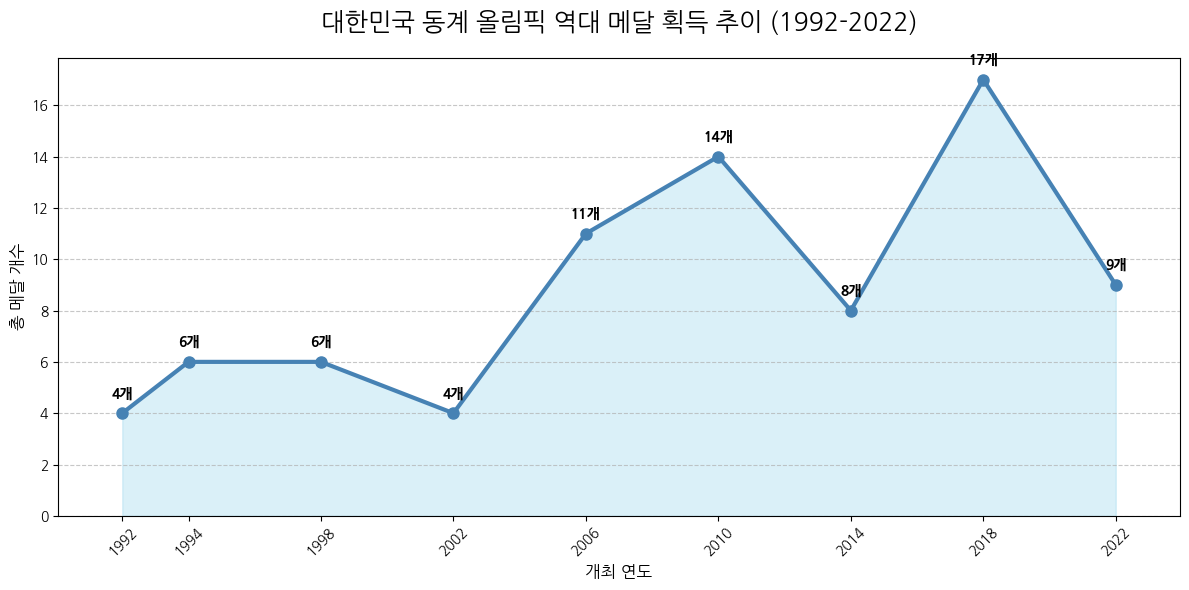

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

# 1. 데이터 로드 및 한국 동계 데이터 필터링
df = pd.read_csv('Olympic_Athlete_Event_Results.csv')
winter_korea = df[(df['edition'].str.contains('Winter')) & (df['country_noc'] == 'KOR')].copy()

# 2. 메달 중복 제거 (단체전 고려: 동일 대회, 종목, 세부이벤트의 메달은 1개로 집계)
korea_medals_clean = winter_korea[winter_korea['medal'].notna()].drop_duplicates(subset=['edition', 'sport', 'event', 'medal'])

# 3. 연도별 메달 개수 집계
# 대회 명칭에서 연도 숫자만 추출 (예: '1992 Winter Olympics' -> 1992)
korea_medals_clean['Year'] = korea_medals_clean['edition'].str.extract('(\d+)').astype(int)
yearly_medals = korea_medals_clean.groupby('Year').size().reset_index(name='Medal_Count')

# 4. 시각화
plt.figure(figsize=(12, 6))

# 막대 그래프와 꺾은선 그래프를 혼합하여 성장세를 강조
plt.bar(yearly_medals['Year'], yearly_medals['Year'].map(lambda x: 0), alpha=0) # 간격 유지를 위한 트릭
plt.plot(yearly_medals['Year'], yearly_medals['Year'].map(lambda x: 0), alpha=0) 

# 실제 데이터 플롯
plt.fill_between(yearly_medals['Year'], yearly_medals['Medal_Count'], color="skyblue", alpha=0.3)
plt.plot(yearly_medals['Year'], yearly_medals['Medal_Count'], color="steelblue", marker='o', linewidth=3, markersize=8)

for i in range(len(yearly_medals)):
    plt.text(yearly_medals['Year'][i],              # x축 위치
             yearly_medals['Medal_Count'][i] + 0.5, # y축 위치 (점보다 약간 위에 표시)
             f"{yearly_medals['Medal_Count'][i]}개", # 표시할 텍스트
             ha='center',                           # 가로 정렬 (중앙)
             va='bottom',                           # 세로 정렬 (하단)
             fontsize=10,                           # 글자 크기
             fontweight='bold',                     # 글자 굵기
             color='black')                         # 글자 색상

# 그래프 꾸미기
plt.title('대한민국 동계 올림픽 역대 메달 획득 추이 (1992-2022)', fontsize=18, pad=20)
plt.xlabel('개최 연도', fontsize=12)
plt.ylabel('총 메달 개수', fontsize=12)
plt.xticks(yearly_medals['Year'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
C:\Users\KDS21\AppData\Local\Temp\ipykernel_20256\1322994435.py:12: SyntaxWarning: invalid escape sequence '\d'
  korea_medals['Year'] = korea_medals['edition'].str.extract('(\d+)').astype(int)
C:\Users\KDS21\AppData\Local\Temp\ipykernel_20256\1322994435.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medal_counts = korea_medals.groupby(['Year', 'sport', 'medal']).size().unstack(fill_value=0).stack().reset_index(name='Count')


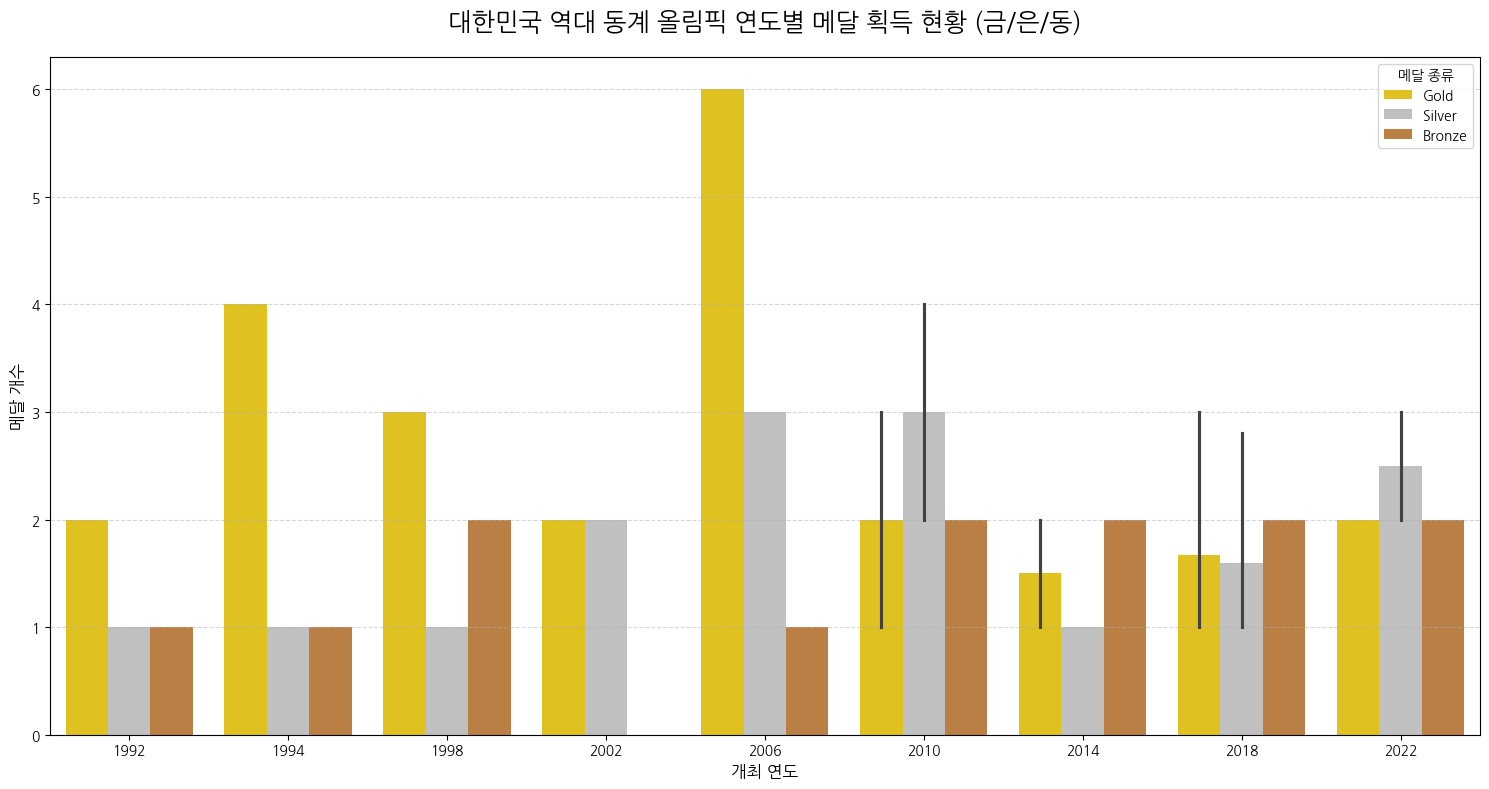

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 1. 데이터 로드 및 필터링
df = pd.read_csv('Olympic_Athlete_Event_Results.csv')
winter_korea = df[(df['edition'].str.contains('Winter')) & (df['country_noc'] == 'KOR')].copy()

# 2. 메달 중복 제거 및 연도 추출
korea_medals = winter_korea[winter_korea['medal'].notna()].drop_duplicates(subset=['edition', 'sport', 'event', 'medal'])
korea_medals['Year'] = korea_medals['edition'].str.extract('(\d+)').astype(int)

# 3. 메달 등급을 숫자로 정렬하기 위해 카테고리 설정 (금 -> 은 -> 동 순서)
korea_medals['medal'] = pd.Categorical(korea_medals['medal'], categories=['Gold', 'Silver', 'Bronze'], ordered=True)

# 4. 연도별, 종목별, 메달별로 그룹화하여 개수 집계
medal_counts = korea_medals.groupby(['Year', 'sport', 'medal']).size().unstack(fill_value=0).stack().reset_index(name='Count')

# 5. 시각화 (FacetGrid를 사용하여 연도별로 종목별 메달 현황 출력)
# 여기서는 가장 최근 5개 대회를 중점적으로 보거나, 전체를 한 화면에 막대로 표시합니다.
plt.figure(figsize=(15, 8))

# Seaborn의 barplot을 활용하여 누적은 아니지만 종목별로 금,은,동을 나란히 표시
sns.barplot(data=medal_counts[medal_counts['Count'] > 0], 
            x='Year', y='Count', hue='medal', 
            palette={'Gold': '#FFD700', 'Silver': '#C0C0C0', 'Bronze': '#CD7F32'})

plt.title('대한민국 역대 동계 올림픽 연도별 메달 획득 현황 (금/은/동)', fontsize=18, pad=20)
plt.xlabel('개최 연도', fontsize=12)
plt.ylabel('메달 개수', fontsize=12)
plt.legend(title='메달 종류')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
C:\Users\KDS21\AppData\Local\Temp\ipykernel_20256\1694461418.py:12: SyntaxWarning: invalid escape sequence '\d'
  korea_medals['Year'] = korea_medals['edition'].str.extract('(\d+)').astype(int)


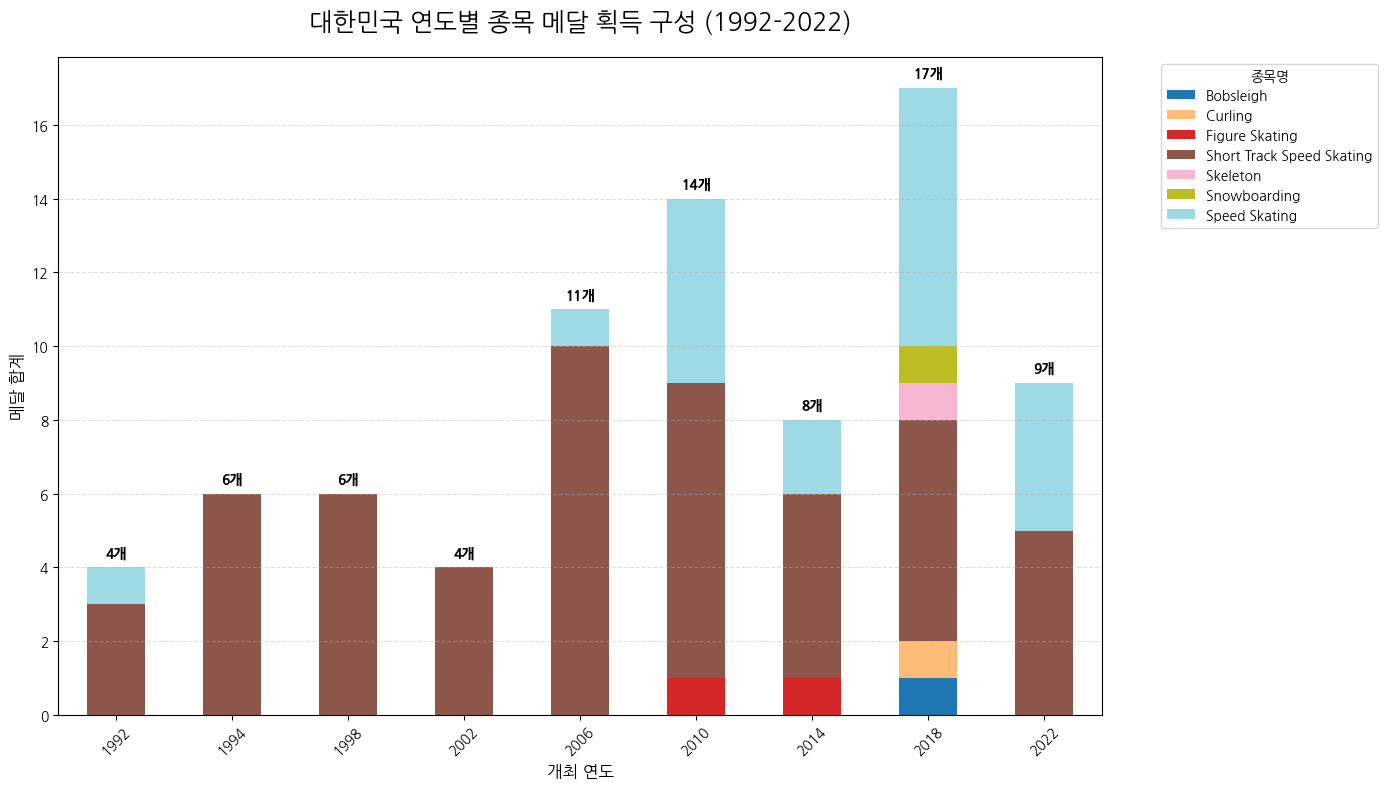

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 1. 데이터 로드 및 필터링
df = pd.read_csv('Olympic_Athlete_Event_Results.csv')
winter_korea = df[(df['edition'].str.contains('Winter')) & (df['country_noc'] == 'KOR')].copy()

# 2. 메달 중복 제거 및 연도 추출
korea_medals = winter_korea[winter_korea['medal'].notna()].drop_duplicates(subset=['edition', 'sport', 'event', 'medal'])
korea_medals['Year'] = korea_medals['edition'].str.extract('(\d+)').astype(int)

# 3. 데이터 재구조화 (Pivot)
# 연도별로 각 종목의 메달 개수를 카운트합니다.
pivot_df = korea_medals.groupby(['Year', 'sport']).size().unstack(fill_value=0)

# 4. 시각화
ax = pivot_df.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab20')

# 그래프 꾸미기
plt.title('대한민국 연도별 종목 메달 획득 구성 (1992-2022)', fontsize=18, pad=20)
plt.xlabel('개최 연도', fontsize=12)
plt.ylabel('메달 합계', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='종목명', bbox_to_anchor=(1.05, 1), loc='upper left') # 범례를 밖으로 이동
plt.grid(axis='y', linestyle='--', alpha=0.4)

# 💡 막대 위에 총 메달 개수 표시
for i, total in enumerate(pivot_df.sum(axis=1)):
    plt.text(i, total + 0.3, f'{int(total)}개', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
C:\Users\KDS21\AppData\Local\Temp\ipykernel_20256\259467256.py:12: SyntaxWarning: invalid escape sequence '\d'
  korea_medals['Year'] = korea_medals['edition'].str.extract('(\d+)').astype(int)


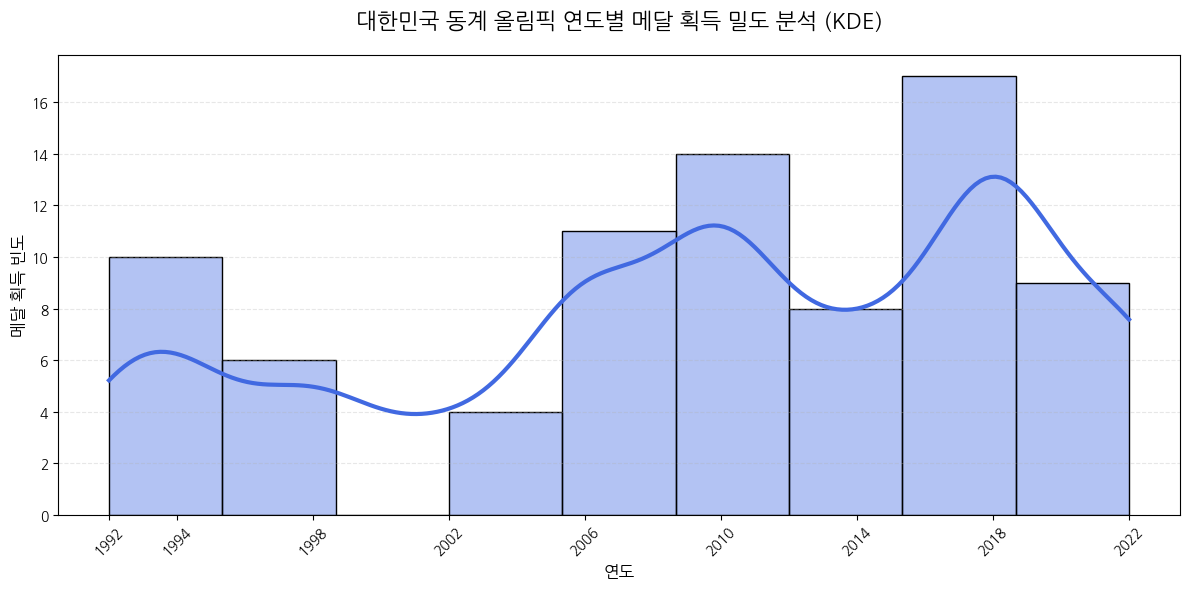

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 1. 데이터 로드 및 필터링
df = pd.read_csv('Olympic_Athlete_Event_Results.csv')
winter_korea = df[(df['edition'].str.contains('Winter')) & (df['country_noc'] == 'KOR')].copy()

# 2. 메달 중복 제거 및 연도 추출
korea_medals = winter_korea[winter_korea['medal'].notna()].drop_duplicates(subset=['edition', 'sport', 'event', 'medal'])
korea_medals['Year'] = korea_medals['edition'].str.extract('(\d+)').astype(int)

# 3. 시각화
plt.figure(figsize=(12, 6))

# sns.histplot의 kde=True 옵션을 사용하면 히스토그램 위에 밀도 곡선을 그려줍니다.
# bw_adjust는 곡선의 부드러운 정도를 조절합니다.
sns.histplot(data=korea_medals, x='Year', kde=True, bins=len(korea_medals['Year'].unique()), 
             color='royalblue', alpha=0.4, kde_kws={'bw_adjust': 0.5}, line_kws={'linewidth': 3})

plt.title('대한민국 동계 올림픽 연도별 메달 획득 밀도 분석 (KDE)', fontsize=16, pad=20)
plt.xlabel('연도', fontsize=12)
plt.ylabel('메달 획득 빈도', fontsize=12)
plt.xticks(sorted(korea_medals['Year'].unique()), rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()